In [35]:
pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 6.2 MB/s eta 0:00:00


In [60]:
#importing required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency,f_oneway
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder,OneHotEncoder,StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import optuna
import joblib

In [61]:
df=pd.read_csv("/content/train.csv")

In [62]:
df.shape

(381109, 12)

In [ ]:
df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [ ]:
df.tail()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
381104,381105,Male,74,1,26.0,1,1-2 Year,No,30170.0,26.0,88,0
381105,381106,Male,30,1,37.0,1,< 1 Year,No,40016.0,152.0,131,0
381106,381107,Male,21,1,30.0,1,< 1 Year,No,35118.0,160.0,161,0
381107,381108,Female,68,1,14.0,0,> 2 Years,Yes,44617.0,124.0,74,0
381108,381109,Male,46,1,29.0,0,1-2 Year,No,41777.0,26.0,237,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  object 
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  object 
 7   Vehicle_Damage        381109 non-null  object 
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 34.9+ MB


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isna().sum()

,0
id,0
Gender,0
Age,0
Driving_License,0
Region_Code,0
Previously_Insured,0
Vehicle_Age,0
Vehicle_Damage,0
Annual_Premium,0
Policy_Sales_Channel,0


In [63]:
#seperating columns w.r.t their data types
num_cols=['Age','Annual_Premium','Vintage']
cat_cols=['Gender','Driving_License','Previously_Insured','Vehicle_Age','Vehicle_Damage','Response']
code_cols=['Region_Code','Policy_Sales_Channel']

In [64]:
#dropping the id column
df.drop(columns='id',axis=1,inplace=True)

In [ ]:
#sampling the data to 50000 rows
sample=df.sample(n=50000,random_state=42)

In [ ]:
sample.shape

(50000, 11)

In [ ]:
sample.head()

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
200222,Female,21,1,3.0,1,< 1 Year,No,20408.0,160.0,72,0
49766,Male,55,1,15.0,0,1-2 Year,Yes,37498.0,26.0,102,0
172201,Female,41,1,3.0,0,1-2 Year,Yes,2630.0,26.0,90,0
160713,Female,26,1,11.0,0,< 1 Year,No,2630.0,151.0,268,0
53272,Male,51,1,40.0,0,1-2 Year,Yes,34006.0,124.0,265,0


In [ ]:
sample.reset_index(drop=True,inplace=True)

In [ ]:
sample.head()

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,Female,21,1,3.0,1,< 1 Year,No,20408.0,160.0,72,0
1,Male,55,1,15.0,0,1-2 Year,Yes,37498.0,26.0,102,0
2,Female,41,1,3.0,0,1-2 Year,Yes,2630.0,26.0,90,0
3,Female,26,1,11.0,0,< 1 Year,No,2630.0,151.0,268,0
4,Male,51,1,40.0,0,1-2 Year,Yes,34006.0,124.0,265,0


In [ ]:
# Full dataset proportions
print("Full dataset:")
print(df['Response'].value_counts(normalize=True) * 100)

# Your 50K sample proportions
print("\nSample (50K):")
print(sample['Response'].value_counts(normalize=True) * 100)

Full dataset:
Response
0    87.743664
1    12.256336
Name: proportion, dtype: float64

Sample (50K):
Response
0    87.474
1    12.526
Name: proportion, dtype: float64


In [ ]:
#Univariate Analysis

In [ ]:
# calculating value_counts for cat_cols
for col in cat_cols:
    print(sample[col].value_counts())
    print()

Gender
Male      27099
Female    22901
Name: count, dtype: int64

Driving_License
1    49902
0       98
Name: count, dtype: int64

Previously_Insured
0    27169
1    22831
Name: count, dtype: int64

Vehicle_Age
1-2 Year     26225
< 1 Year     21713
> 2 Years     2062
Name: count, dtype: int64

Vehicle_Damage
Yes    25222
No     24778
Name: count, dtype: int64

Response
0    43737
1     6263
Name: count, dtype: int64



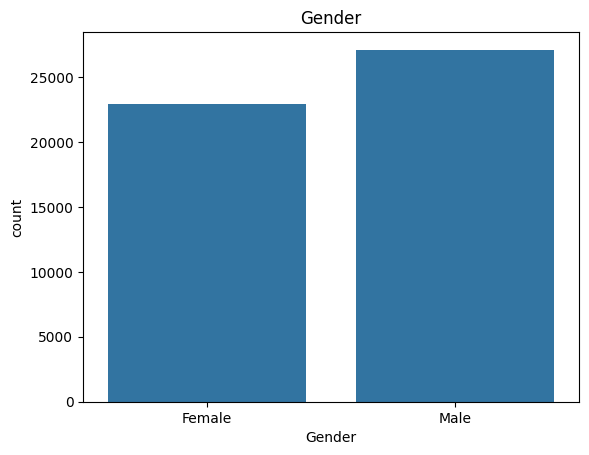

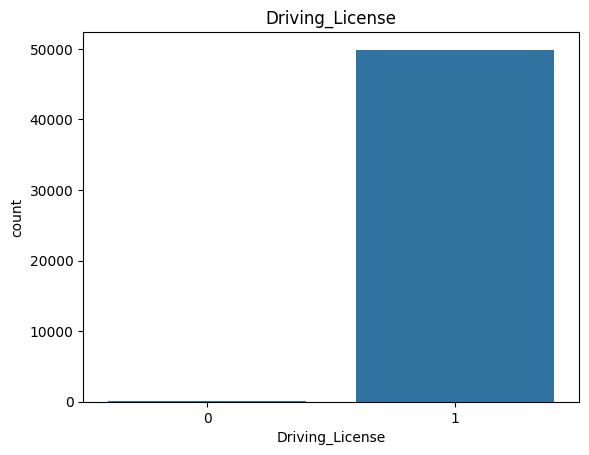

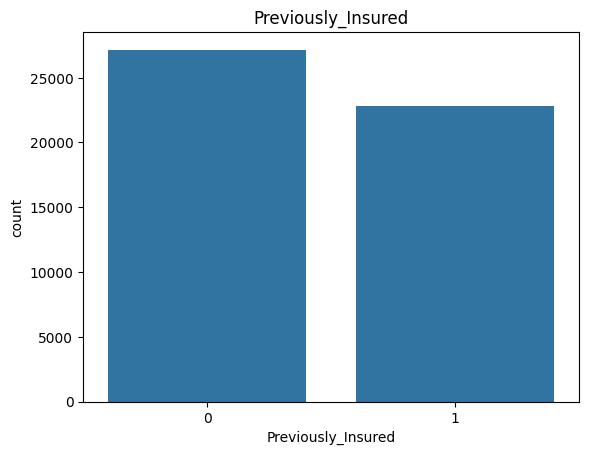

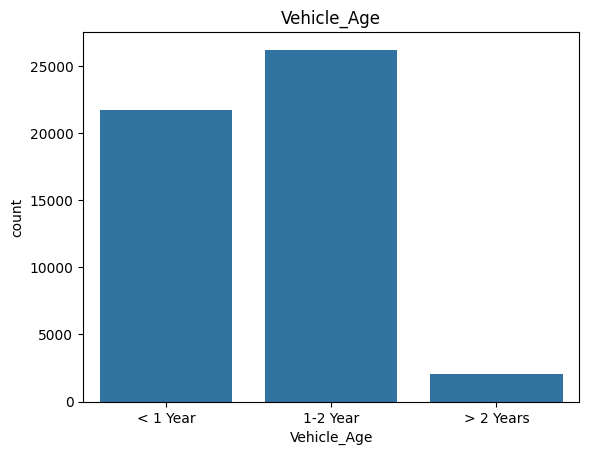

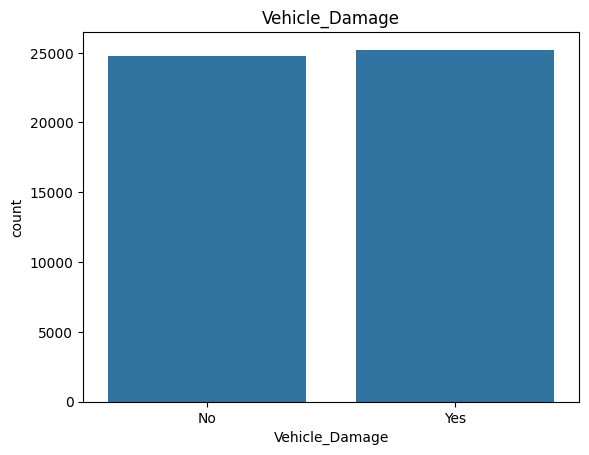

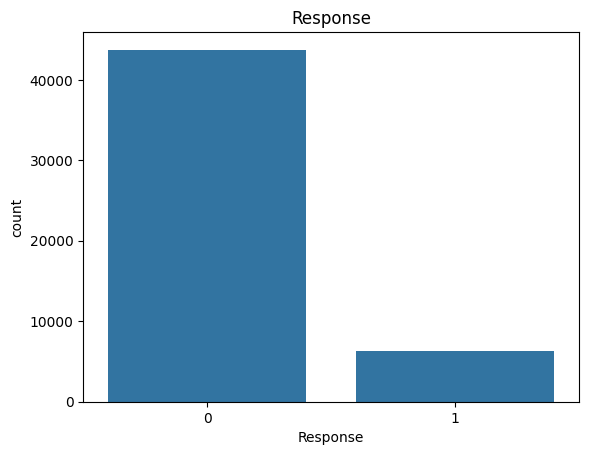

In [ ]:
#visualizing above cat_cols using barplot
for col in cat_cols:
    sns.countplot(sample,x=col)
    plt.title(col)
    plt.show()

In [ ]:
for col in code_cols:
  print(df[col].value_counts())
  print()

Region_Code
28.0    106415
8.0      33877
46.0     19749
41.0     18263
15.0     13308
30.0     12191
29.0     11065
50.0     10243
3.0       9251
11.0      9232
36.0      8797
33.0      7654
47.0      7436
35.0      6942
6.0       6280
45.0      5605
37.0      5501
18.0      5153
48.0      4681
14.0      4678
39.0      4644
10.0      4374
21.0      4266
2.0       4038
13.0      4036
7.0       3279
12.0      3198
9.0       3101
27.0      2823
32.0      2787
43.0      2639
17.0      2617
26.0      2587
25.0      2503
24.0      2415
38.0      2026
0.0       2021
16.0      2007
23.0      1960
31.0      1960
20.0      1935
49.0      1832
4.0       1801
34.0      1664
19.0      1535
22.0      1309
40.0      1295
5.0       1279
1.0       1008
44.0       808
42.0       591
52.0       267
51.0       183
Name: count, dtype: int64

Policy_Sales_Channel
152.0    134784
26.0      79700
124.0     73995
160.0     21779
156.0     10661
          ...  
149.0         1
43.0          1
144.0         1
1

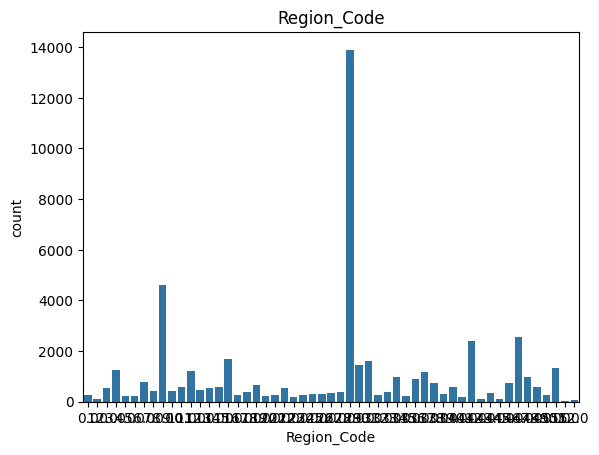

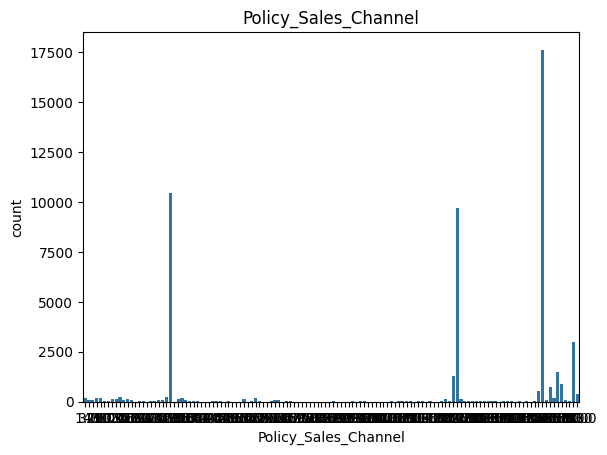

In [ ]:
#visualizing above cat_cols using barplot
for col in code_cols:
    sns.countplot(sample,x=col,)
    plt.title(col)
    plt.show()

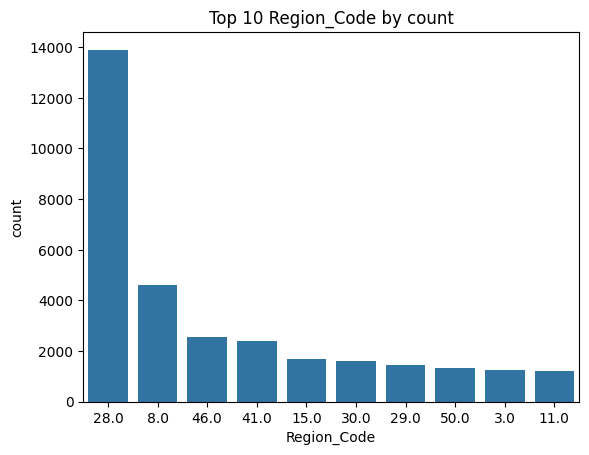

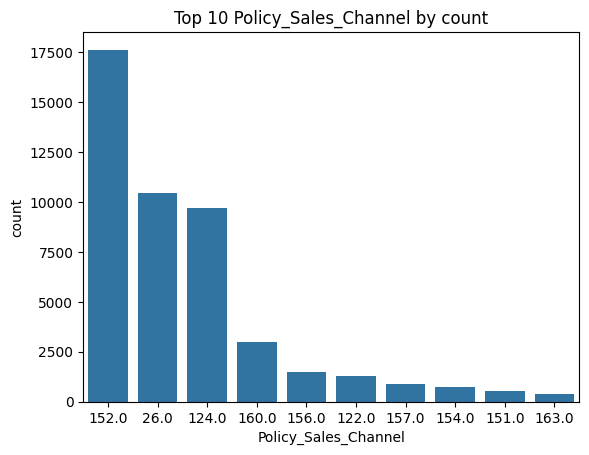

In [ ]:
#visualizing above cat_cols using barplot
for col in code_cols:
    sns.countplot(sample,x=col,order=sample[col].value_counts().iloc[:10].index)
    plt.title(f'Top 10 {col} by count')
    plt.show()

In [ ]:
# Frequency/count encoding — replace each category with how often it appears (simple, keeps it numeric, works well with ANNs)
# Important: Do this AFTER train-test split
# Remember what we discussed earlier — fit the frequency mapping (or determine top 10 categories) only on the training set, then apply the same mapping to the test set:
# For an ANN project, frequency encoding is simpler, keeps your feature count low, and tends to work well. Go with that unless your project specifically wants to demonstrate one-hot encoding techniques.
# Good question — here's the short answer: yes, treat them as numeric, but you don't need to redo full EDA on them.
# Why they become numeric
# Once you apply frequency encoding, Region_Code_freq and Policy_Sales_Channel_freq are no longer categories — they're counts (integers), so technically they behave like numeric features from that point on (for scaling, distribution checks, etc.).
# What you should still do
# 1. Scale them — since ANNs are sensitive to feature scale, include these new frequency columns in your scaling step (StandardScaler/MinMaxScaler) along with Age, Annual_Premium, Vintage, etc.
# 2. Drop the original columns — once you've created Region_Code_freq, drop the original Region_Code (and same for Policy_Sales_Channel). Keeping both is redundant and could confuse the model:
# 1. Split first
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, stratify=y, random_state=42
# )

# # 2. Fit frequency encoding on TRAIN only
# region_freq = X_train['Region_Code'].value_counts()
# channel_freq = X_train['Policy_Sales_Channel'].value_counts()

# # 3. Apply the SAME mapping to both train and test
# X_train['Region_Code_freq'] = X_train['Region_Code'].map(region_freq)
# X_test['Region_Code_freq'] = X_test['Region_Code'].map(region_freq)

# X_train['Policy_Sales_Channel_freq'] = X_train['Policy_Sales_Channel'].map(channel_freq)
# X_test['Policy_Sales_Channel_freq'] = X_test['Policy_Sales_Channel'].map(channel_freq)

# # 4. Handle unseen categories in test set (categories in test not present in train)
# X_test['Region_Code_freq'].fillna(0, inplace=True)
# X_test['Policy_Sales_Channel_freq'].fillna(0, inplace=True)

# # 5. NOW drop the original columns from BOTH train and test
# X_train.drop(columns=['Region_Code', 'Policy_Sales_Channel'], inplace=True)
# X_test.drop(columns=['Region_Code', 'Policy_Sales_Channel'], inplace=True)
#print(X_train.columns.equals(X_test.columns))  # should print True

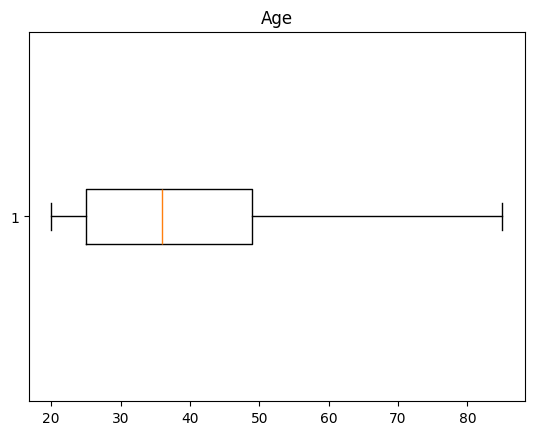

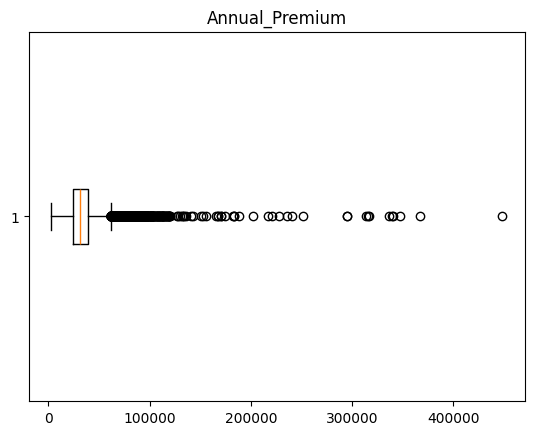

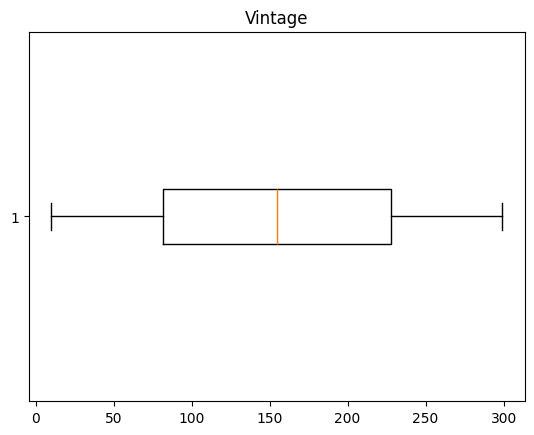

In [ ]:
for col in num_cols:
  plt.boxplot(sample[col],vert=False)
  plt.title(col)
  plt.show()

In [ ]:
# Nice, clear picture here. Let's break down each:

# ## Age
# - Range: ~20 to 85
# - No outliers (whiskers cover the full range, no dots beyond them)
# - Median ~36, right-skewed slightly (box is wider on the lower side, median line closer to left of box)
# - **Clean feature, no treatment needed**

# ## Annual_Premium ⚠️
# - Heavily right-skewed with **a lot of outliers** — dense clustering of outlier points from ~60K all the way out to ~450K
# - Median is low (~30K), most data compressed near the bottom, but a long tail stretches very far right
# - This is very common for premium/income-type financial data

# ### What to do about it
# You have a few options — don't just delete these outliers blindly, since they could be genuine high-value customers:

# 1. **Log transformation** (recommended) — compresses the long tail, makes distribution more normal-like, ANNs handle this much better than raw skewed data:
# ```python
# df['Annual_Premium_log'] = np.log1p(df['Annual_Premium'])
# ```
# 2. **Capping/Winsorizing** — cap extreme values at a percentile (e.g., 99th percentile) instead of removing rows
# 3. **Leave as-is + rely on scaling** — StandardScaler/RobustScaler alone won't fully fix skewness, but RobustScaler (uses median/IQR instead of mean/std) is less sensitive to these outliers than StandardScaler

# **My recommendation:** Apply log transform, then scale. This is a very standard and easy-to-justify step in your report for financial/monetary columns like premiums or income.

# ## Vintage
# - Range: ~10 to 300, no outliers, fairly symmetric
# - Median ~155, box roughly centered
# - **Clean feature, no treatment needed**

# ## Summary for your report
# | Column | Outliers? | Action |
# |---|---|---|
# | Age | No | Scale only |
# | Annual_Premium | Yes, heavy | Log transform → then scale |
# | Vintage | No | Scale only |

# Want the code for applying the log transform (remembering to do it after train-test split, consistent with what we discussed), or should we move to bivariate analysis next?

In [ ]:
#Bivariate Analysis

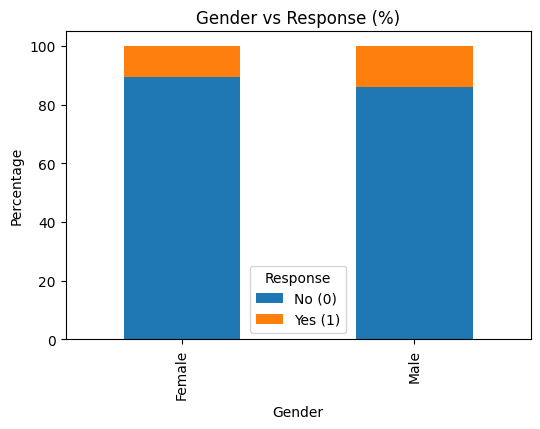

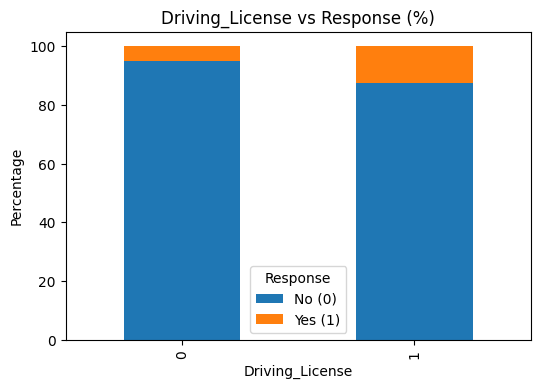

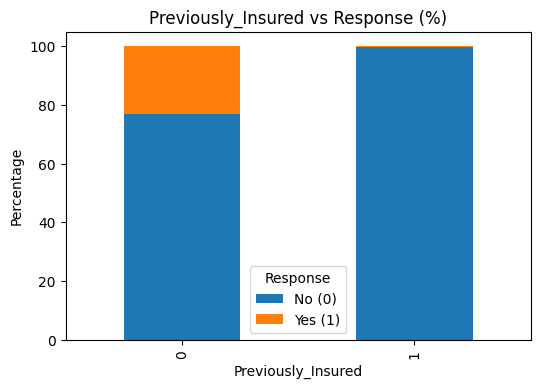

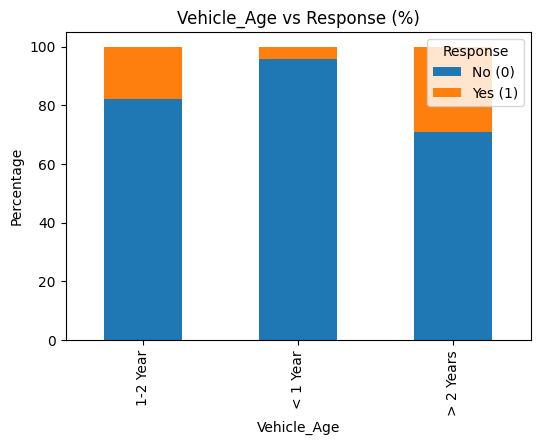

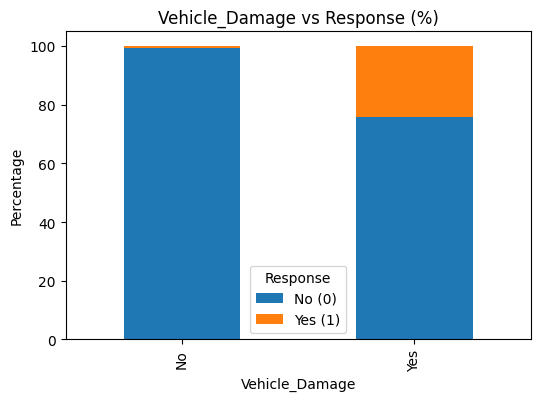

In [ ]:
#cat_cols vs target(response)
for col in cat_cols[:-1]:
    ct = pd.crosstab(sample[col], sample['Response'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, figsize=(6,4))
    plt.title(f'{col} vs Response (%)')
    plt.ylabel('Percentage')
    plt.legend(title='Response', labels=['No (0)', 'Yes (1)'])
    plt.show()

In [ ]:
# These are excellent — very clear signal here. Let's break down each one:

# ## Gender vs Response
# - Female: ~10% Yes
# - Male: ~14% Yes
# - Slight difference, Males respond a bit more, but **not a strong predictor** on its own.

# ## Driving_License vs Response
# - License=0: ~5% Yes
# - License=1: ~12% Yes
# - Some difference, but remember from univariate — License=0 has almost no data points (barely visible bar). This difference could just be noise from a tiny sample size, **not reliable**. Weak feature overall.

# ## Previously_Insured vs Response ⭐ (Strongest predictor so far)
# - Previously_Insured=0: ~23% Yes
# - Previously_Insured=1: ~0-1% Yes (almost entirely "No")
# - **Huge, clean separation.** This confirms our earlier hypothesis — customers who already have insurance almost never respond "Yes" to cross-sell. This will likely be one of your model's most important features.

# ## Vehicle_Age vs Response
# - `< 1 Year`: ~4% Yes
# - `1-2 Year`: ~18% Yes
# - `> 2 Years`: ~29% Yes
# - **Clear increasing trend** — older vehicles → higher interest in insurance. Makes intuitive sense (older vehicles are more damage-prone/valuable to insure). Strong predictor.

# ## Vehicle_Damage vs Response ⭐ (Also very strong)
# - Damage=No: ~1% Yes
# - Damage=Yes: ~24% Yes
# - **Massive separation**, similar strength to Previously_Insured. Customers with past vehicle damage are dramatically more likely to want insurance.

# ## Summary for your report

# | Feature | Predictive Strength |
# |---|---|
# | Previously_Insured | Very Strong ⭐ |
# | Vehicle_Damage | Very Strong ⭐ |
# | Vehicle_Age | Strong |
# | Gender | Weak |
# | Driving_License | Very Weak (likely noise) |

# This is a great finding — you now have solid evidence-based reasoning (not just guesses) for feature importance discussion in your report, and it'll help explain the ANN's behavior later (e.g., during feature importance/SHAP analysis if you do that).

# Next up: numerical features (Age, Annual_Premium, Vintage) vs Response — want to run those boxplots/KDE plots and share them?

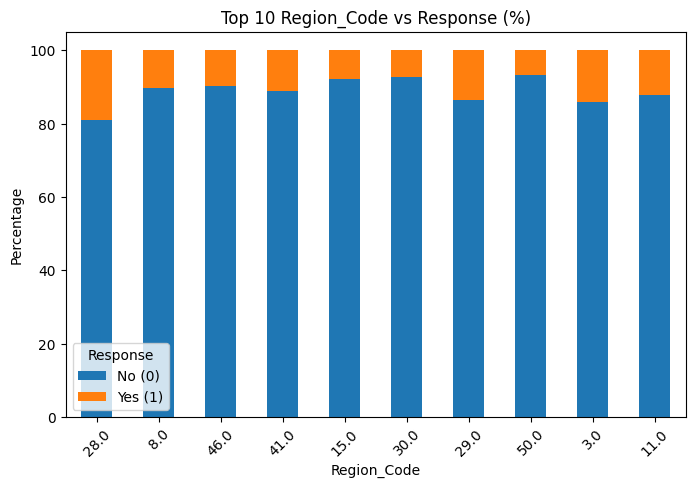

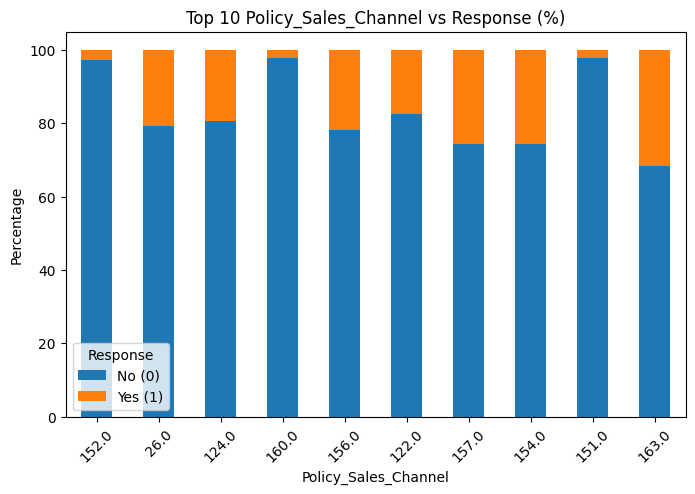

In [ ]:
#code cols vs target(response)
for col in code_cols:
    top10 = sample[col].value_counts().iloc[:10].index
    subset = sample[sample[col].isin(top10)]

    ct = pd.crosstab(subset[col], subset['Response'], normalize='index') * 100
    ct = ct.loc[top10]  # keep same order as top10 frequency

    ct.plot(kind='bar', stacked=True, figsize=(8,5))
    plt.title(f'Top 10 {col} vs Response (%)')
    plt.ylabel('Percentage')
    plt.xlabel(col)
    plt.legend(title='Response', labels=['No (0)', 'Yes (1)'])
    plt.xticks(rotation=45)
    plt.show()

In [ ]:
# Good results — clear contrast between the two.

# ## Region_Code vs Response
# Response rate ranges roughly **7%–19%** across the top 10 regions (e.g., `28.0` ~19% Yes, `50.0` ~7% Yes). There's some variation, but it's **fairly mild and gradual** — no region stands out dramatically. This suggests Region_Code has **weak-to-moderate predictive power**. It might add a little value, but it's not a standout feature like Previously_Insured or Vehicle_Damage.

# ## Policy_Sales_Channel vs Response ⭐ (Much stronger signal)
# This one shows a **much bigger spread**:
# - Channel `152.0` and `151.0` → only ~2-3% Yes (barely any interest)
# - Channel `163.0` → ~32% Yes
# - Channel `157.0`, `154.0` → ~25% Yes
# - Channel `26.0`, `156.0`, `122.0` → ~18-22% Yes

# That's roughly a **10x difference** in response rate between the best and worst channels. This is a **strong, meaningful predictor** — likely because different sales channels represent different customer engagement methods (e.g., agent call vs. online form vs. branch visit), which naturally affects how receptive customers are.

# ## Summary update

# | Feature | Predictive Strength |
# |---|---|
# | Previously_Insured | Very Strong ⭐ |
# | Vehicle_Damage | Very Strong ⭐ |
# | **Policy_Sales_Channel** | **Strong ⭐ (new finding)** |
# | Vehicle_Age | Strong |
# | Region_Code | Weak-Moderate |
# | Gender | Weak |
# | Driving_License | Very Weak (likely noise) |

# ## Important note for encoding
# Since `Policy_Sales_Channel` clearly matters, this justifies your earlier choice to use **frequency encoding** (or even consider target encoding for this specific column, given how strongly it correlates with the target) rather than dropping or oversimplifying it. Frequency encoding will at least preserve *some* of this signal (channels used more often vs rarely), though it won't fully capture the response-rate pattern the way target encoding would.

# Ready to move to numerical features (Age, Annual_Premium, Vintage) vs Response next?

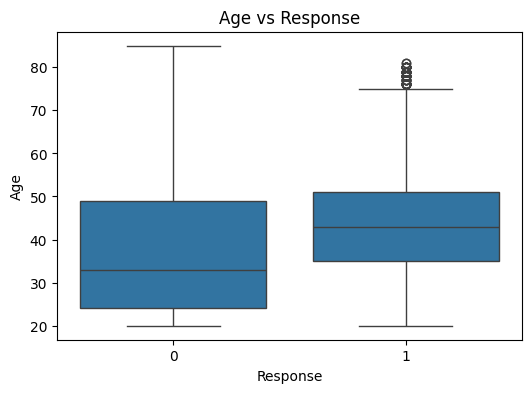

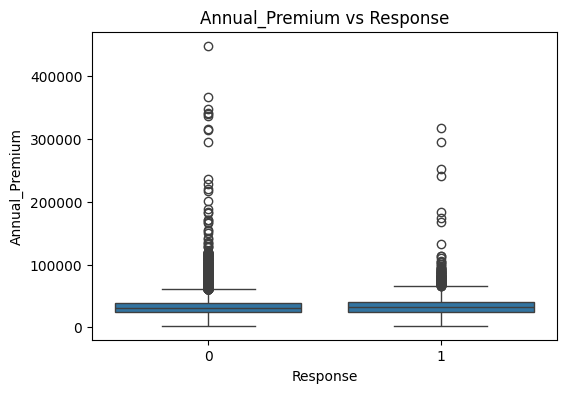

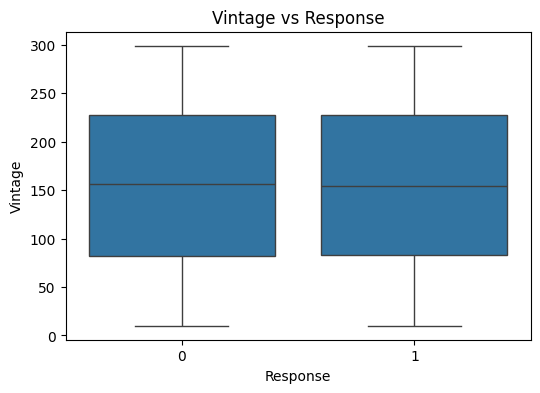

In [ ]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Response', y=col, data=sample)
    plt.title(f'{col} vs Response')
    plt.show()

In [ ]:
# Good, clear results. Here's the breakdown:

# ## Age vs Response — Moderate signal
# - Response=0: median age ~33
# - Response=1: median age ~43
# - **Clear shift** — customers who respond "Yes" tend to be older, matching what we predicted from the Vehicle_Age pattern (older customers likely have owned vehicles longer, more damage history, etc.)
# - **Moderate predictor**, useful for the model.

# ## Annual_Premium vs Response — No real signal
# - Both boxes look nearly identical — same median (~30K), similar IQR, similar outlier pattern
# - **No meaningful difference** between responders and non-responders
# - This confirms what we suspected earlier: premium amount reflects **policy/vehicle pricing**, not genuine interest in cross-sell insurance. **Weak predictor** on its own — though after your log transform, it may still help the model slightly in combination with other features, but don't expect much standalone signal.

# ## Vintage vs Response — No signal
# - Nearly identical distributions for both classes — same median (~155), same spread
# - **No difference at all**. This makes sense — how long someone's been a customer doesn't really predict interest in a *different* insurance product.
# - **Not a useful predictor**, likely just adds noise.

# ## Updated full summary

# | Feature | Predictive Strength |
# |---|---|
# | Previously_Insured | Very Strong ⭐ |
# | Vehicle_Damage | Very Strong ⭐ |
# | Policy_Sales_Channel | Strong ⭐ |
# | Vehicle_Age | Strong |
# | Age | Moderate |
# | Region_Code | Weak-Moderate |
# | Gender | Weak |
# | Annual_Premium | Weak |
# | Driving_License | Very Weak |
# | Vintage | Very Weak / Noise |

# ## What this means for your project
# You now have a data-backed ranking of feature importance **before even training a model** — this is genuinely valuable for your report. A few options going forward:

# 1. **Keep all features** and let the ANN learn to downweight the weak ones (ANNs are generally fine with a few uninformative features)
# 2. **Drop Vintage and Driving_License** if you want a leaner model and cleaner report — since they add no real signal, they're mostly just extra parameters
# 3. Later, after training, use **feature importance/permutation importance** on your ANN to double check if these EDA findings match what the model actually learned — great way to validate your analysis

# You've done a genuinely thorough EDA. Ready to move to preprocessing (transformations, encoding, scaling) and then the ANN architecture next?

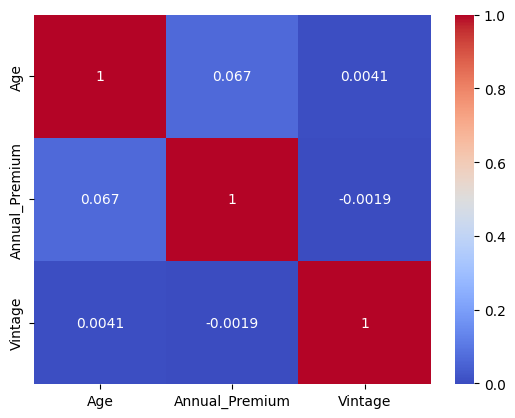

In [ ]:
sns.heatmap(sample[num_cols].corr(), annot=True, cmap='coolwarm')
plt.show()

In [ ]:
contingency = pd.crosstab(sample['Vehicle_Damage'], sample['Previously_Insured'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"p-value: {p}")
if p<0.05:
  print('significant relationship')
else:
  print('no significant relationship')

p-value: 0.0
significant relationship


In [ ]:
# This confirms **Vehicle_Damage and Previously_Insured are statistically associated** — not independent of each other.

# ## What p-value: 0.0 means
# The Chi-square test gave a p-value essentially at 0 (far below the 0.05 threshold), so you reject the null hypothesis of independence. In plain terms: **whether a customer has vehicle damage is strongly related to whether they were previously insured.**

# ## Why this makes sense
# This is intuitive if you think about it:
# - Customers who are **already insured** are more likely to have their damage handled/claimed through their existing policy, or their driving/vehicle profile that led to insurance in the first place correlates with damage history
# - Customers who are **not previously insured** and have had damage represent a very specific risk profile — likely why they're now more open to buying insurance (which matches your earlier finding that this combination has extremely high Response rates)

# ## Important distinction for your report
# Chi-square tells you these two features are **related to each other**, not just to the target. This is useful context, but doesn't mean you should drop one of them — remember from bivariate analysis, **both are independently very strong predictors of Response**. Even though they're correlated with each other, they can still both add value to an ANN (unlike linear models, ANNs don't break down due to this kind of association).

# ## One caveat to mention in your report
# With p-value exactly 0.0 (or very close to it), always mention that Chi-square is sensitive to large sample sizes — even at your 50K sample, a fairly small/moderate practical association can still produce a tiny p-value. So it's worth also checking the **effect size** (Cramér's V) alongside the p-value, since p-value alone doesn't tell you *how strong* the relationship is, just *whether* one exists:

# ```python
# import numpy as np

# n = contingency.sum().sum()
# min_dim = min(contingency.shape) - 1
# cramers_v = np.sqrt(chi2 / (n * min_dim))
# print(f"Cramér's V: {cramers_v}")
# ```

# - Cramér's V close to 0 → weak association despite significant p-value
# - Cramér's V closer to 0.3-0.5+ → moderate-to-strong association

# This would tell you whether the "significant relationship" is practically meaningful or just a large-sample-size artifact.

# Want to run that, or move on to preprocessing now that your EDA is comprehensive?

In [ ]:
import numpy as np

n = contingency.sum().sum()
min_dim = min(contingency.shape) - 1
cramers_v = np.sqrt(chi2 / (n * min_dim))
print(f"Cramér's V: {cramers_v}")

Cramér's V: 0.8218006624694398


In [ ]:
# Cramér's V of **0.82** is a very strong association — this isn't just a large-sample artifact, it's a genuinely strong practical relationship between `Vehicle_Damage` and `Previously_Insured`.

# ## Interpretation scale for Cramér's V
# | Value | Strength |
# |---|---|
# | 0.0–0.1 | Negligible |
# | 0.1–0.3 | Weak |
# | 0.3–0.5 | Moderate |
# | 0.5+ | Strong |

# At 0.82, these two features are **strongly linked** — almost like near-duplicate information in some sense. This is a solid multivariate finding: it explains *why* both features individually showed such extreme response-rate separation in your bivariate analysis (they're capturing overlapping customer risk profiles).

# ## For your report
# You can now write something like: *"Chi-square testing confirmed a statistically significant association between Vehicle_Damage and Previously_Insured (p < 0.001), with Cramér's V = 0.82 indicating a strong practical relationship — consistent with both features independently showing strong predictive power toward Response."*

# ---

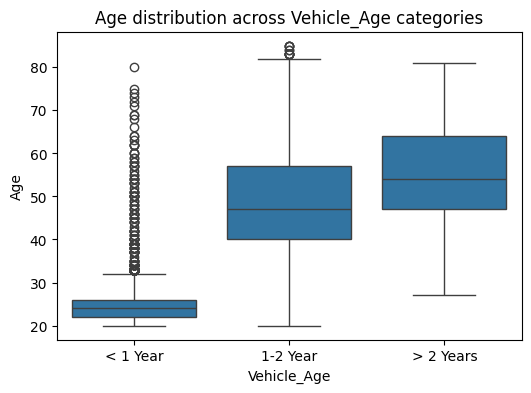

F-statistic: 42064.01343775173
p-value: 0.0


In [ ]:
# Boxplot
plt.figure(figsize=(6,4))
sns.boxplot(x='Vehicle_Age', y='Age', data=sample)
plt.title('Age distribution across Vehicle_Age categories')
plt.show()

# ANOVA test
group1 = sample[sample['Vehicle_Age'] == '< 1 Year']['Age']
group2 = sample[sample['Vehicle_Age'] == '1-2 Year']['Age']
group3 = sample[sample['Vehicle_Age'] == '> 2 Years']['Age']

f_stat, p_value = f_oneway(group1, group2, group3)
print(f"F-statistic: {f_stat}")
print(f"p-value: {p_value}")

In [ ]:
# This confirms exactly what we expected — a very strong, clear relationship.

# ## Reading the results

# **Boxplot:**
# - `< 1 Year`: median age ~24, tightly clustered (younger customers, likely first-time car owners/recent buyers)
# - `1-2 Year`: median age ~47, much wider spread
# - `> 2 Years`: median age ~54, highest of the three groups

# **ANOVA:**
# - F-statistic: 42,064 (very large)
# - p-value: 0.0 (essentially zero)

# This confirms **Age and Vehicle_Age are strongly related** — customers with newer vehicles tend to be considerably younger, while customers with older vehicles tend to be older. Makes complete sense (younger people buy new cars more often; older customers hold onto vehicles longer).

# ## What this means for your project

# This is a great multivariate finding to include in your report:
# > *"ANOVA testing confirmed a highly significant relationship between Age and Vehicle_Age (F = 42064.01, p < 0.001), with boxplots showing median age increasing from ~24 years (Vehicle_Age < 1 Year) to ~54 years (Vehicle_Age > 2 Years). This explains the overlapping directional trends observed in bivariate analysis, where both Age and Vehicle_Age independently showed increasing Response rates with older values."*

# This ties your whole EDA together nicely — you've now shown *why* certain features behave similarly with the target (they're capturing related underlying customer profiles), not just *that* they do.

# ## Your EDA is now complete ✅
# - Univariate (categorical + numerical)
# - Bivariate (all features vs target)
# - Multivariate (correlation heatmap, Chi-square + Cramér's V, ANOVA)

# This is genuinely thorough — solid foundation for your report. Ready to move to **preprocessing** (log transform, encoding, scaling) and then building the ANN?

In [ ]:
#multivariate

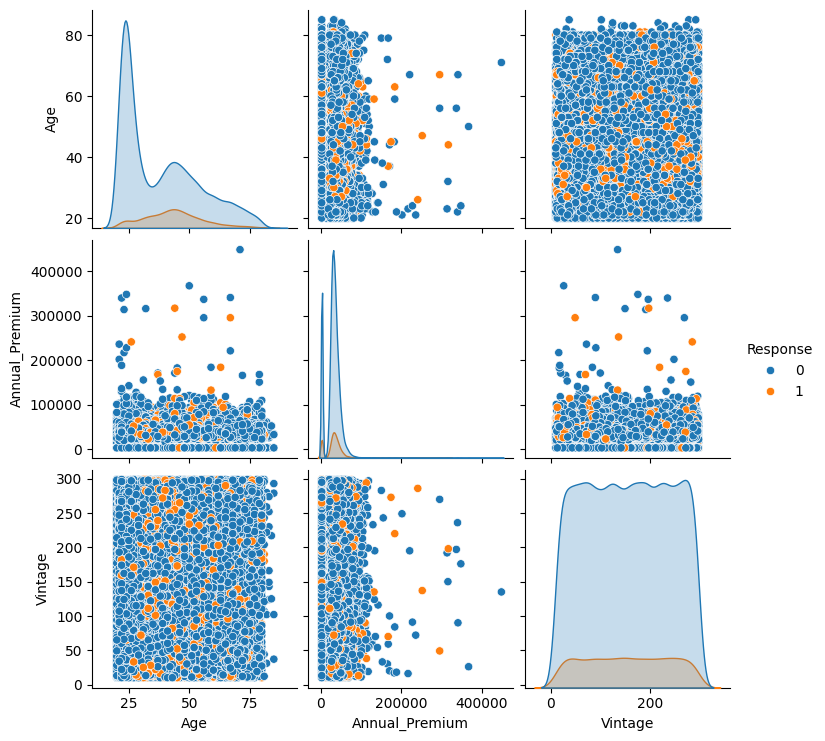

In [ ]:
numerical_cols = ['Age', 'Annual_Premium', 'Vintage', 'Response']
sns.pairplot(sample[numerical_cols], hue='Response', diag_kind='kde')
plt.show()

In [ ]:
ct = pd.crosstab([sample['Previously_Insured'], sample['Vehicle_Damage']], sample['Response'], normalize='index') * 100
print(ct)

Response                                   0          1
Previously_Insured Vehicle_Damage                      
0                  No              96.006192   3.993808
                   Yes             74.468441  25.531559
1                  No              99.972155   0.027845
                   Yes             98.752923   1.247077


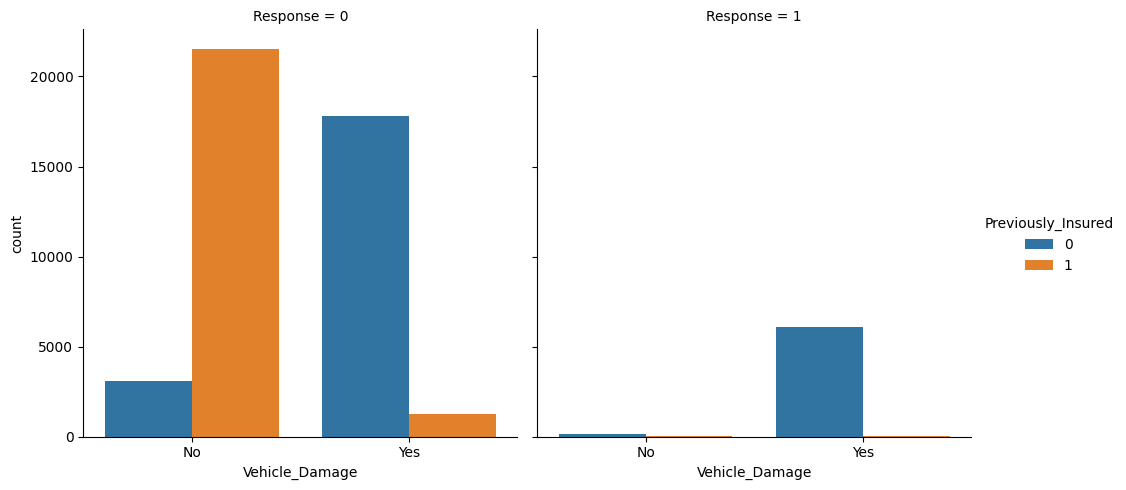

In [ ]:
sns.catplot(x='Vehicle_Damage', hue='Previously_Insured', col='Response',
            kind='count', data=sample)

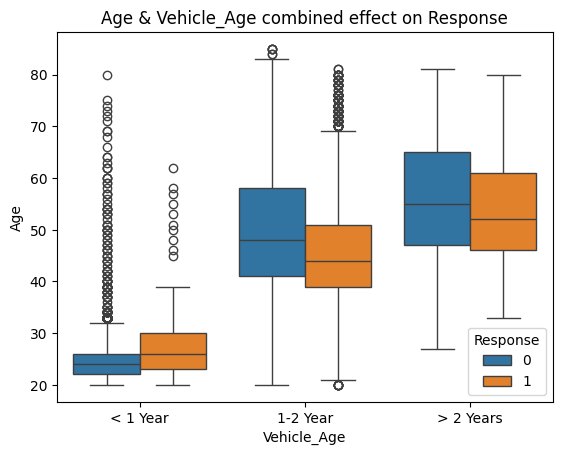

In [ ]:
sns.boxplot(x='Vehicle_Age', y='Age', hue='Response', data=sample)
plt.title('Age & Vehicle_Age combined effect on Response')
plt.show()

In [55]:
#splitting

In [65]:
X=df.drop(columns='Response',axis=1)
y=df['Response']

In [66]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

In [67]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(304887, 10)
(76222, 10)
(304887,)
(76222,)


In [68]:
X_train.reset_index(drop=True,inplace=True)
X_test.reset_index(drop=True,inplace=True)
y_train.reset_index(drop=True,inplace=True)
y_test.reset_index(drop=True,inplace=True)

In [69]:
#Preprocessing

In [70]:
X_train.head()

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage
0,Male,22,1,40.0,0,< 1 Year,Yes,25455.0,152.0,203
1,Female,26,1,8.0,1,< 1 Year,No,38393.0,26.0,45
2,Female,32,1,28.0,0,< 1 Year,Yes,32118.0,122.0,35
3,Male,32,1,37.0,0,< 1 Year,Yes,37711.0,152.0,215
4,Female,24,1,28.0,0,< 1 Year,Yes,48706.0,156.0,222


In [71]:
# for col in ['Gender','Vehicle_Damage']:
#   ohe=OneHotEncoder(drop='first')
#   x1=pd.DataFrame(ohe.fit_transform(X_train[[col]]).toarray(),columns=ohe.get_feature_names_out())
#   x2=pd.DataFrame(ohe.transform(X_test[[col]]).toarray(),columns=ohe.get_feature_names_out())
#   X_train=pd.concat([X_train,x1],axis=1)
#   X_test=pd.concat([X_test,x2],axis=1)

In [72]:
X_train.columns

Index(['Gender', 'Age', 'Driving_License', 'Region_Code', 'Previously_Insured',
       'Vehicle_Age', 'Vehicle_Damage', 'Annual_Premium',
       'Policy_Sales_Channel', 'Vintage'],
      dtype='object')

In [73]:
cols = ['Gender', 'Vehicle_Damage']

ohe = OneHotEncoder(drop='first', sparse_output=False)  # sparse_output=False avoids .toarray()
ohe.fit(X_train[cols])

# Transform both sets at once
train_encoded = pd.DataFrame(
    ohe.transform(X_train[cols]),
    columns=ohe.get_feature_names_out(cols),
    index=X_train.index          # <-- fixes the alignment bug
)
test_encoded = pd.DataFrame(
    ohe.transform(X_test[cols]),
    columns=ohe.get_feature_names_out(cols),
    index=X_test.index           # <-- fixes the alignment bug
)

# Attach and drop originals
X_train = pd.concat([X_train.drop(columns=cols), train_encoded], axis=1)
X_test = pd.concat([X_test.drop(columns=cols), test_encoded], axis=1)

# Save the fitted encoder for later use
joblib.dump(ohe, 'onehot_encoder.pkl')

['onehot_encoder.pkl']

In [77]:
# To reload later

# ohe = joblib.load('onehot_encoder.pkl')
# new_encoded = ohe.transform(new_data[['Gender', 'Vehicle_Damage']])

In [74]:
print(X_train.shape)
print(X_test.shape)

(304887, 10)
(76222, 10)


In [ ]:
X_train.head()

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Gender_Male,Vehicle_Damage_Yes
0,Male,22,1,40.0,0,< 1 Year,Yes,25455.0,152.0,203,1.0,1.0
1,Female,26,1,8.0,1,< 1 Year,No,38393.0,26.0,45,0.0,0.0
2,Female,32,1,28.0,0,< 1 Year,Yes,32118.0,122.0,35,0.0,1.0
3,Male,32,1,37.0,0,< 1 Year,Yes,37711.0,152.0,215,1.0,1.0
4,Female,24,1,28.0,0,< 1 Year,Yes,48706.0,156.0,222,0.0,1.0


In [ ]:
X_test.head()

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Gender_Male,Vehicle_Damage_Yes
0,Male,54,1,28.0,0,> 2 Years,Yes,75219.0,26.0,53,1.0,1.0
1,Female,26,1,3.0,0,1-2 Year,Yes,19738.0,156.0,280,0.0,1.0
2,Male,25,1,28.0,0,< 1 Year,Yes,61524.0,124.0,255,1.0,1.0
3,Male,29,1,24.0,0,1-2 Year,Yes,2630.0,157.0,235,1.0,1.0
4,Female,28,1,28.0,0,< 1 Year,Yes,51473.0,26.0,243,0.0,1.0


In [75]:
# X_train.drop(columns=['Gender','Vehicle_Damage'],axis=1,inplace=True)
# X_test.drop(columns=['Gender','Vehicle_Damage'],axis=1,inplace=True)

In [76]:
print(X_train.shape)
print(X_test.shape)

(304887, 10)
(76222, 10)


In [ ]:
X_train.head()

,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Annual_Premium,Policy_Sales_Channel,Vintage,Gender_Male,Vehicle_Damage_Yes
0,22,1,40.0,0,< 1 Year,25455.0,152.0,203,1.0,1.0
1,26,1,8.0,1,< 1 Year,38393.0,26.0,45,0.0,0.0
2,32,1,28.0,0,< 1 Year,32118.0,122.0,35,0.0,1.0
3,32,1,37.0,0,< 1 Year,37711.0,152.0,215,1.0,1.0
4,24,1,28.0,0,< 1 Year,48706.0,156.0,222,0.0,1.0


In [ ]:
X_test.head()

,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Annual_Premium,Policy_Sales_Channel,Vintage,Gender_Male,Vehicle_Damage_Yes
0,54,1,28.0,0,> 2 Years,75219.0,26.0,53,1.0,1.0
1,26,1,3.0,0,1-2 Year,19738.0,156.0,280,0.0,1.0
2,25,1,28.0,0,< 1 Year,61524.0,124.0,255,1.0,1.0
3,29,1,24.0,0,1-2 Year,2630.0,157.0,235,1.0,1.0
4,28,1,28.0,0,< 1 Year,51473.0,26.0,243,0.0,1.0


In [14]:
X_train.isna().sum()

,0
Age,0
Driving_License,0
Region_Code,0
Previously_Insured,0
Vehicle_Age,0
Annual_Premium,0
Policy_Sales_Channel,0
Vintage,0
Gender_Male,0
Vehicle_Damage_Yes,0


In [15]:
X_test.isna().sum()

,0
Age,0
Driving_License,0
Region_Code,0
Previously_Insured,0
Vehicle_Age,0
Annual_Premium,0
Policy_Sales_Channel,0
Vintage,0
Gender_Male,0
Vehicle_Damage_Yes,0


In [78]:
oe=OrdinalEncoder(categories=[['< 1 Year', '1-2 Year', '> 2 Years']])
X_train['Vehicle_Age']=oe.fit_transform(X_train[['Vehicle_Age']])
X_test['Vehicle_Age']=oe.transform(X_test[['Vehicle_Age']])

In [88]:
joblib.dump(oe,'ordinal_encoder.pkl')

['ordinal_encoder.pkl']

In [79]:
#Frequency encode Region_Code and Policy_Sales_Channel
region_freq = X_train['Region_Code'].value_counts()
channel_freq = X_train['Policy_Sales_Channel'].value_counts()

X_train['Region_Code_freq'] = X_train['Region_Code'].map(region_freq)
X_test['Region_Code_freq'] = X_test['Region_Code'].map(region_freq)

X_train['Policy_Sales_Channel_freq'] = X_train['Policy_Sales_Channel'].map(channel_freq)
X_test['Policy_Sales_Channel_freq'] = X_test['Policy_Sales_Channel'].map(channel_freq)

In [80]:
# Handle unseen categories in test
X_test['Region_Code_freq'].fillna(0, inplace=True)
X_test['Policy_Sales_Channel_freq'].fillna(0, inplace=True)

/tmp/ipykernel_2474/1687457212.py:2: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



/tmp/ipykernel_2474/1687457212.py:3: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or

In [81]:
# Drop originals
X_train.drop(columns=['Region_Code', 'Policy_Sales_Channel'], inplace=True)
X_test.drop(columns=['Region_Code', 'Policy_Sales_Channel'], inplace=True)

In [82]:
print(X_train.shape)
print(X_test.shape)

(304887, 10)
(76222, 10)


In [83]:
import numpy as np

X_train['Annual_Premium'] = np.log1p(X_train['Annual_Premium'])
X_test['Annual_Premium'] = np.log1p(X_test['Annual_Premium'])

In [84]:
n1 = ['Age', 'Annual_Premium', 'Vintage', 'Region_Code_freq', 'Policy_Sales_Channel_freq']

scaler = StandardScaler()
X_train[n1] = scaler.fit_transform(X_train[n1])
X_test[n1] = scaler.transform(X_test[n1])

In [85]:

print(X_train.columns.equals(X_test.columns))  # should be True
print(X_train.isnull().sum())  # should be all 0
X_train.head()

True
Age                          0
Driving_License              0
Previously_Insured           0
Vehicle_Age                  0
Annual_Premium               0
Vintage                      0
Gender_Male                  0
Vehicle_Damage_Yes           0
Region_Code_freq             0
Policy_Sales_Channel_freq    0
dtype: int64


,Age,Driving_License,Previously_Insured,Vehicle_Age,Annual_Premium,Vintage,Gender_Male,Vehicle_Damage_Yes,Region_Code_freq,Policy_Sales_Channel_freq
0,-1.084538,1,0,0.0,0.128783,0.580945,1.0,1.0,-0.851704,1.121181
1,-0.826727,1,1,0.0,0.537434,-1.307422,0.0,0.0,-0.098407,-0.027440
2,-0.440011,1,0,0.0,0.359978,-1.426939,0.0,1.0,1.576053,-1.473504
3,-0.440011,1,0,0.0,0.519611,0.724365,1.0,1.0,-0.755013,1.121181
4,-0.955632,1,0,0.0,0.774024,0.808027,0.0,1.0,1.576053,-1.459993


In [86]:
X_train['Vehicle_Age'].value_counts()

,count
Vehicle_Age,
1.0,160195
0.0,131852
2.0,12840


In [87]:
# Preprocessing objects - pkl is fine here
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(region_freq, 'region_freq.pkl')
joblib.dump(channel_freq, 'channel_freq.pkl')

['channel_freq.pkl']

In [25]:
model=Sequential()
model.add(Dense(32,activation='relu',input_shape=(X_train.shape[1],)),Dropout(0.2))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
model.add(Dense(16,activation='relu'),Dropout(0.2))
model.add(Dense(8,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [27]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,025 (4.00 KB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

In [29]:
early_stop = EarlyStopping(
    monitor='val_auc',
    mode='max',
    patience=5,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
953/953 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8718 - auc: 0.8037 - loss: 0.2978 - precision: 0.1330 - recall: 0.0087 - val_accuracy: 0.8766 - val_auc: 0.8444 - val_loss: 0.2725 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/50
953/953 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8776 - auc: 0.8447 - loss: 0.2704 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.8766 - val_auc: 0.8471 - val_loss: 0.2721 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/50
953/953 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8776 - auc: 0.8467 - loss: 0.2695 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.8766 - val_auc: 0.8482 - val_loss: 0.2699 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/50
953/953 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8776 - auc: 0.8477 - loss: 0.2690 - precision: 1.0000 - recall: 3.3508e-05 - val_accuracy: 0.8766 - val_auc: 0.8495 - val_loss: 0.2695 - val_precision: 0.0000e+00 - va

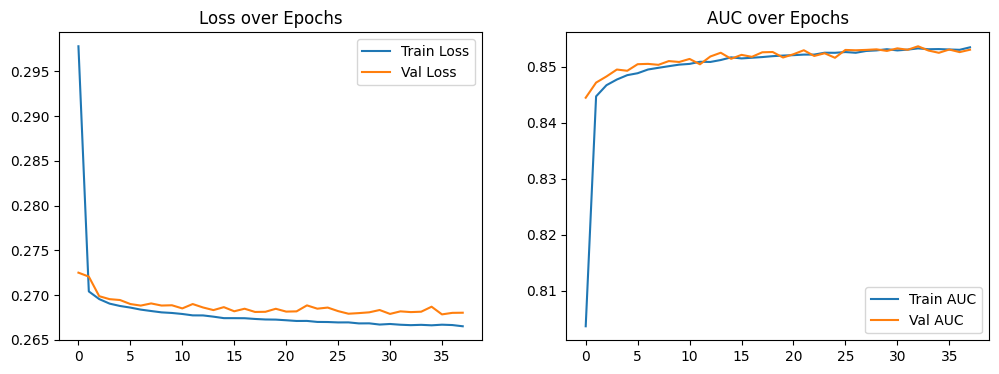

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Val AUC')
plt.title('AUC over Epochs')
plt.legend()

plt.show()

In [30]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print(class_weight_dict)

{0: np.float64(0.5698417682482366), 1: np.float64(4.079519910083494)}


In [ ]:
# No problem, let's break it down line by line.

# ## Goal
# You want to tell the ANN: *"the minority class (Response=1) is rare, so pay more attention to it during training"* — `class_weight_dict` is just a dictionary that stores **how much extra importance to give each class**.

# ## Line by line

# ```python
# from sklearn.utils.class_weight import compute_class_weight
# ```
# This imports a helper function from scikit-learn that automatically calculates appropriate weights for imbalanced classes — you don't have to compute the math yourself.

# ```python
# import numpy as np
# ```
# Just importing numpy, used for `np.unique()` below.

# ```python
# class_weights = compute_class_weight(
#     class_weight='balanced',
#     classes=np.unique(y_train),
#     y=y_train
# )
# ```
# This is the core calculation. Let's unpack the arguments:
# - `class_weight='balanced'` — tells sklearn to use a standard formula that automatically gives higher weight to rarer classes and lower weight to common classes
# - `classes=np.unique(y_train)` — this just gets the unique class labels in your target, i.e., `[0, 1]` (since your `Response` is binary)
# - `y=y_train` — your actual training labels, so sklearn can see how many 0s and 1s there are

# **What 'balanced' actually computes internally:**
# ```
# weight_for_class = total_samples / (number_of_classes × count_of_that_class)
# ```
# So if you have 87.5% Class 0 and 12.5% Class 1:
# - Class 0 (common) → gets a **small weight** (since it's already well-represented)
# - Class 1 (rare) → gets a **large weight** (since it's underrepresented, so each occurrence "counts more")

# This returns something like `array([0.57, 4.0])` — meaning class 0 gets weight ~0.57 and class 1 gets weight ~4.0 (exact numbers depend on your actual class counts).

# ```python
# class_weight_dict = dict(enumerate(class_weights))
# ```
# This just converts that array into a dictionary format that Keras expects: `{0: 0.57, 1: 4.0}`

# - `enumerate(class_weights)` pairs each weight with its index: `(0, 0.57), (1, 4.0)`
# - `dict(...)` converts those pairs into a dictionary: `{0: 0.57, 1: 4.0}`

# ```python
# print(class_weight_dict)
# ```
# Just displays it so you can see the actual values, e.g.:
# ```
# {0: 0.57, 1: 4.03}
# ```

# ## What this means in plain terms
# When training, for every mistake the model makes on a **Class 1 (Yes)** sample, it gets penalized **~4x more** than a mistake on a **Class 0 (No)** sample. This forces the model to actually try to learn patterns for the rare class, instead of ignoring it.

# ## How you use it
# You just pass this dictionary into `model.fit()`:
# ```python
# history = model.fit(
#     X_train, y_train,
#     validation_split=0.2,
#     epochs=50,
#     batch_size=256,
#     class_weight=class_weight_dict,  # <-- this is where it's used
#     callbacks=[early_stop],
#     verbose=1
# )
# ```

# That's it — you don't need to do anything else with `class_weight_dict`, just compute it once and pass it into `.fit()`. Run it and let me know what values you get printed out.




# Class 0 (No) → weight ≈ 0.57 — since this class is common (~87.5%), each mistake on it is penalized less
# Class 1 (Yes) → weight ≈ 4.08 — since this class is rare (~12.5%), each mistake on it is penalized about 7x more heavily than a Class 0 mistake (4.08 / 0.57 ≈ 7.15)

In [31]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=256,
    class_weight=class_weight_dict,   # <-- add this
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
953/953 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6796 - auc: 0.8354 - loss: 0.4490 - precision: 0.2661 - recall: 0.9210 - val_accuracy: 0.6832 - val_auc: 0.8447 - val_loss: 0.4832 - val_precision: 0.2724 - val_recall: 0.9385
Epoch 2/50
953/953 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6908 - auc: 0.8454 - loss: 0.4309 - precision: 0.2743 - recall: 0.9275 - val_accuracy: 0.6776 - val_auc: 0.8474 - val_loss: 0.4864 - val_precision: 0.2701 - val_recall: 0.9474
Epoch 3/50
953/953 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6911 - auc: 0.8473 - loss: 0.4296 - precision: 0.2746 - recall: 0.9285 - val_accuracy: 0.6915 - val_auc: 0.8492 - val_loss: 0.4690 - val_precision: 0.2768 - val_recall: 0.9306
Epoch 4/50
953/953 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6917 - auc: 0.8481 - loss: 0.4288 - precision: 0.2751 - recall: 0.9292 - val_accuracy: 0.6836 - val_auc: 0.8488 - val_loss: 0.4746 - val_precision: 0.2730 - val_recall: 0.9407
Epoch 5/50
953/953 ━━━━━━━━━━━━━

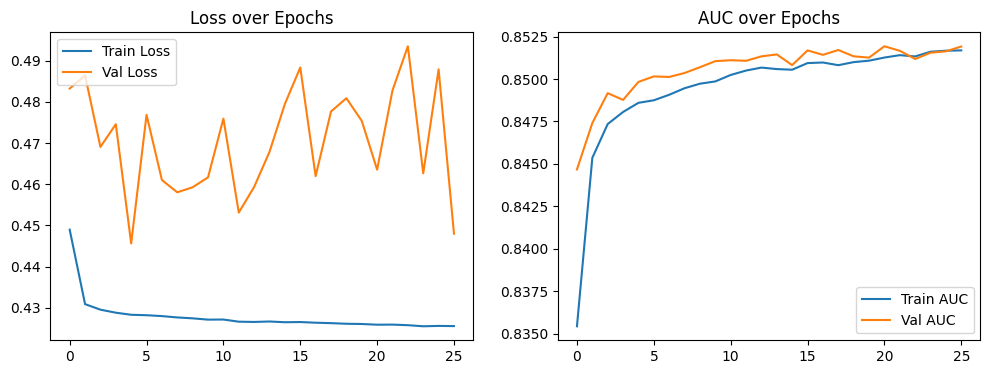

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Val AUC')
plt.title('AUC over Epochs')
plt.legend()

plt.show()

In [33]:
 len(history.history['loss'])

26

2382/2382 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
              precision    recall  f1-score   support

           0       0.98      0.67      0.80     66880
           1       0.28      0.92      0.43      9342

    accuracy                           0.70     76222
   macro avg       0.63      0.80      0.61     76222
weighted avg       0.90      0.70      0.75     76222



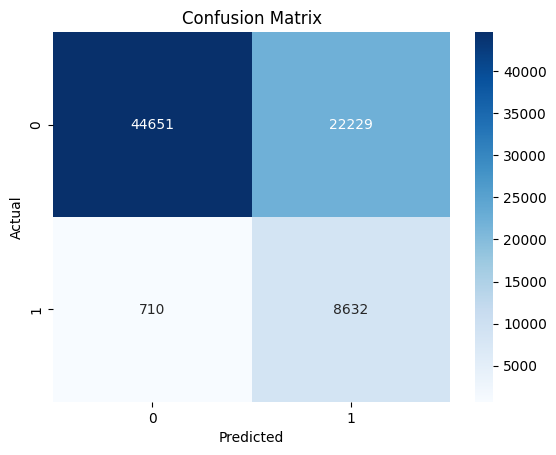

Test AUC: 0.8514363790206598


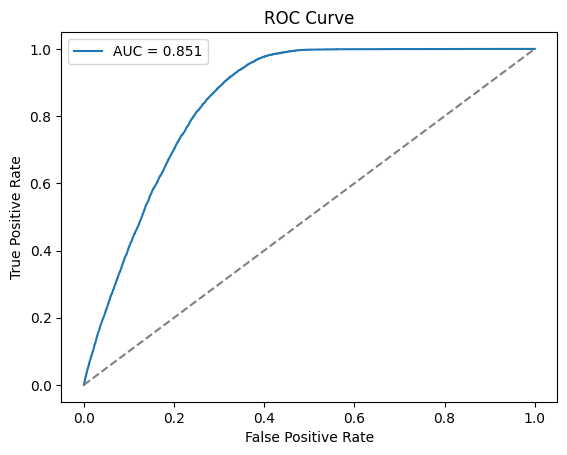

In [34]:
# Predictions
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Classification report
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# ROC-AUC
auc_score = roc_auc_score(y_test, y_pred_prob)
print(f"Test AUC: {auc_score}")

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.3f}')
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [37]:
# How to interpret this for your project/report
# This is a classic precision-recall tradeoff, and the way you frame it matters:

# "Given the business context of cross-sell insurance marketing, prioritizing recall over precision is justified —
# the cost of missing a genuinely interested customer (false negative) is typically higher than the cost of an extra marketing outreach
# to an uninterested customer (false positive). The model achieves 92% recall on the minority class, meaning it successfully identifies the vast
# majority of potential customers, at the cost of increased false positives which is an acceptable trade-off for a marketing/outreach use case."

In [38]:
def objective(trial):
    # Suggest hyperparameters
    units_1 = trial.suggest_int('units_1', 16, 64, step=16)
    units_2 = trial.suggest_int('units_2', 8, 32, step=8)
    dropout_1 = trial.suggest_float('dropout_1', 0.1, 0.5, step=0.1)
    dropout_2 = trial.suggest_float('dropout_2', 0.1, 0.5, step=0.1)
    learning_rate = trial.suggest_categorical('learning_rate', [0.001, 0.0005, 0.0001])
    batch_size = trial.suggest_categorical('batch_size', [128, 256, 512])

    # Build model
    model = Sequential([
        Dense(units_1, activation='relu', input_shape=(X_train.shape[1],)),
        Dropout(dropout_1),
        Dense(units_2, activation='relu'),
        Dropout(dropout_2),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.AUC(name='auc')]
    )

    early_stop = EarlyStopping(monitor='val_auc', mode='max', patience=5, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=30,
        batch_size=batch_size,
        class_weight=class_weight_dict,
        callbacks=[early_stop],
        verbose=0  # keep quiet during tuning, Optuna will show trial progress
    )

    # Return best validation AUC achieved
    best_val_auc = max(history.history['val_auc'])
    return best_val_auc

In [39]:
study = optuna.create_study(direction='maximize')  # we want to maximize AUC
study.optimize(objective, n_trials=20)  # adjust n_trials based on time budget

print("Best trial:")
print(study.best_trial.params)
print(f"Best AUC: {study.best_value}")

[I 2026-07-11 04:33:36,655] A new study created in memory with name: no-name-1e5ab90e-8692-478a-9df0-a052e40ec04c
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
[I 2026-07-11 04:35:00,006] Trial 0 finished with value: 0.8504753112792969 and parameters: {'units_1': 64, 'units_2': 32, 'dropout_1': 0.5, 'dropout_2': 0.30000000000000004, 'learning_rate': 0.001, 'batch_size': 256}. Best is trial 0 with value: 0.8504753112792969.
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity

Best trial:
{'units_1': 64, 'units_2': 24, 'dropout_1': 0.1, 'dropout_2': 0.30000000000000004, 'learning_rate': 0.0005, 'batch_size': 128}
Best AUC: 0.8516614437103271


In [ ]:
# What this tells you (important insight for your report)
# This is actually a valuable finding, not a disappointing one: your baseline architecture was already close to optimal for this dataset. This happens often in real projects — it suggests:

# The model architecture isn't the bottleneck — your features (from the strong EDA work) are doing most of the heavy lifting
# Further architecture tuning has diminishing returns here — the signal in your data is well-captured already by a simple 2-3 layer network
# This is a legitimate, honest conclusion to report: "Hyperparameter tuning via Optuna (20 trials) yielded only marginal improvement over the baseline (AUC 0.851 → 0.8517), suggesting the baseline architecture was already well-suited to the dataset's underlying patterns."

In [40]:
 best_params = study.best_trial.params

final_model = Sequential([
    Dense(best_params['units_1'], activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(best_params['dropout_1']),
    Dense(best_params['units_2'], activation='relu'),
    Dropout(best_params['dropout_2']),
    Dense(1, activation='sigmoid')
])

final_model.compile(
    optimizer=Adam(learning_rate=best_params['learning_rate']),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

early_stop = EarlyStopping(monitor='val_auc', mode='max', patience=5, restore_best_weights=True)

final_history = final_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=best_params['batch_size'],
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
1906/1906 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.6654 - auc: 0.8225 - loss: 0.4676 - precision: 0.2562 - recall: 0.9112 - val_accuracy: 0.6767 - val_auc: 0.8441 - val_loss: 0.4746 - val_precision: 0.2696 - val_recall: 0.9482
Epoch 2/50
1906/1906 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6780 - auc: 0.8380 - loss: 0.4392 - precision: 0.2670 - recall: 0.9352 - val_accuracy: 0.6662 - val_auc: 0.8458 - val_loss: 0.4715 - val_precision: 0.2647 - val_recall: 0.9593
Epoch 3/50
1906/1906 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6808 - auc: 0.8410 - loss: 0.4370 - precision: 0.2689 - recall: 0.9358 - val_accuracy: 0.6842 - val_auc: 0.8474 - val_loss: 0.4624 - val_precision: 0.2732 - val_recall: 0.9397
Epoch 4/50
1906/1906 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6842 - auc: 0.8432 - loss: 0.4349 - precision: 0.2709 - recall: 0.9346 - val_accuracy: 0.6877 - val_auc: 0.8489 - val_loss: 0.4640 - val_precision: 0.2752 - val_recall: 0.9370
Epoch 5/50
1906/1906 ━━━

In [41]:
optuna.visualization.plot_optimization_history(study).show()
optuna.visualization.plot_param_importances(study).show()

In [42]:
# # What to write in your report

# # "Hyperparameter importance analysis revealed that learning rate was the dominant factor influencing model performance
#  (52% relative importance), followed by the dropout rate of the first hidden layer (22%). Architecture-related parameters
#   (number of units) and batch size had comparatively minor impact. This suggests that optimization dynamics (learning rate) mattered
#   more than model capacity for this dataset, further supporting the conclusion that the baseline architecture was already well-suited
#   to the underlying data patterns identified during EDA."

2382/2382 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
              precision    recall  f1-score   support

           0       0.98      0.67      0.80     66880
           1       0.28      0.93      0.43      9342

    accuracy                           0.70     76222
   macro avg       0.63      0.80      0.61     76222
weighted avg       0.90      0.70      0.75     76222



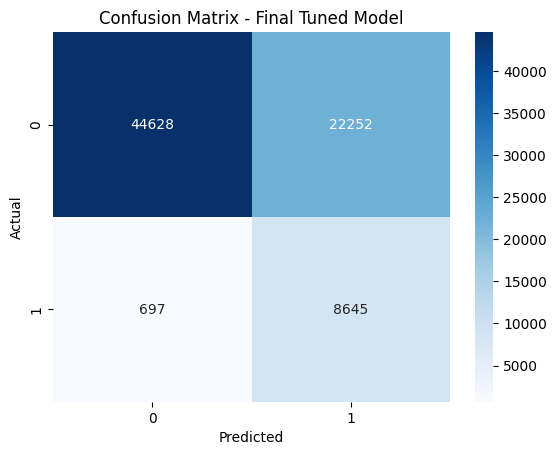

Test AUC (Final Model): 0.8509754655366155


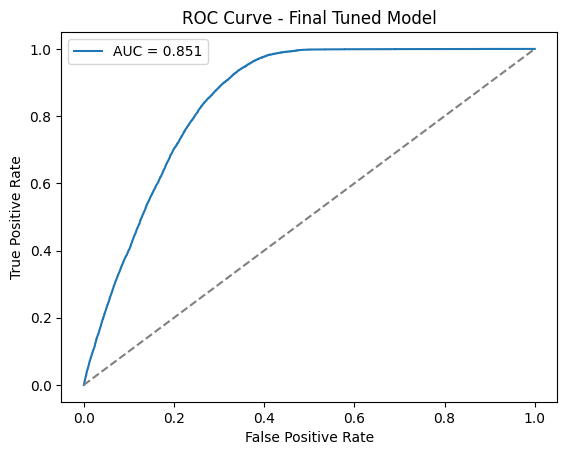

In [43]:
# Predictions
y_pred_prob_final = final_model.predict(X_test)
y_pred_final = (y_pred_prob_final > 0.5).astype(int)

# Classification report
print(classification_report(y_test, y_pred_final))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Final Tuned Model')
plt.show()

# ROC-AUC
auc_score_final = roc_auc_score(y_test, y_pred_prob_final)
print(f"Test AUC (Final Model): {auc_score_final}")

fpr, tpr, _ = roc_curve(y_test, y_pred_prob_final)
plt.plot(fpr, tpr, label=f'AUC = {auc_score_final:.3f}')
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Final Tuned Model')
plt.legend()
plt.show()

In [44]:
# What this confirms
# The tuned model is virtually identical to the baseline — a tiny improvement in recall (697 vs 710 false negatives, 13 fewer missed customers)
# but essentially the same overall performance across every metric. This validates exactly what you found in the Optuna hyperparameter importance plot:
#  your baseline architecture was already close to optimal for this dataset.

In [45]:
# This is a good, honest result for your report
# Rather than framing this as "tuning didn't help," frame it as a validated finding:

# "Hyperparameter tuning via Optuna (20 trials, Bayesian optimization) was conducted to systematically search the hyperparameter space.
# The tuned model achieved nearly identical performance to the baseline (Test AUC: 0.851 vs 0.851; Recall: 0.93 vs 0.92),
#  confirming that the baseline architecture was already well-suited to the dataset. This is further supported by the hyperparameter importance analysis,
#  which showed learning rate (52%) and dropout (22%) as the most influential factors — both of which were already reasonably set in the baseline configuration."

In [46]:
# Your project is essentially complete. Final structure for your report:

# EDA — Univariate, Bivariate, Multivariate (comprehensive, with statistical tests — Chi-square, Cramér's V, ANOVA)
# Preprocessing — Encoding, frequency encoding, log transform, scaling, stratified split
# Baseline ANN — Architecture, class imbalance handling, training curves
# Hyperparameter Tuning — Optuna, optimization history, parameter importance
# Final Evaluation — Confusion matrix, classification report, ROC-AUC, comparison table
# Conclusion — Key predictors identified (Previously_Insured, Vehicle_Damage, Policy_Sales_Channel), business interpretation of precision-recall tradeoff, model performance summary

In [47]:
# One optional addition
# Since your Recall(0.93)/Precision(0.28) tradeoff is central to your story, consider adding the precision-recall curve (mentioned earlier) and a note about how the business could choose a different threshold depending on cost tolerance for false positives vs false negatives.
# Want help writing up any specific section of the report (e.g., the conclusion, or a summary table), or are you good to write it up yourself from here?

In [48]:
final_model.save('final_ann_model.h5')

In [49]:
# Also save the preprocessing objects
# This is easy to forget but important — if you ever want to make a fresh prediction later,
# you need the exact same scaler and encoding mappings used during training, not new ones.
# import joblib

# joblib.dump(scaler, 'scaler.pkl')
# joblib.dump(region_freq, 'region_freq.pkl')
# joblib.dump(channel_freq, 'channel_freq.pkl')


# To reload later
# from tensorflow.keras.models import load_model
# import joblib

# model = load_model('final_ann_model.keras')
# scaler = joblib.load('scaler.pkl')
# region_freq = joblib.load('region_freq.pkl')
# channel_freq = joblib.load('channel_freq.pkl')


# One more tip for Colab
# Since Colab's runtime refrom google.colab import drive
# drive.mount('/content/drive')

# final_model.save('/content/drive/MyDrive/final_ann_model.keras')sets, download the saved files locally or save them to Google Drive so they persist:
